In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
from check_time import extract_vars

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42869,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46857,Total threads: 4
Dashboard: http://127.0.0.1:44555/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:42925,


2025-12-02 16:09:13,442 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:09:13,490 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:10:31,741 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:11:06,513 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:11:11,479 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:46549' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('array-98f8cea64a44a2e8c70b2a16c683805a', 0, 0)} (stimulus_id='handle-worker-cleanup-1764688271.4792564')
2025-12-02 16:11:11,486 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:11:33,259 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:12:05,994 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:12:49,514 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:14:00,469 - distributed.nanny - WARNING - Restarting worker
2025-12-02 16:14:06,498 - distributed

In [3]:
#client.close()

In [4]:
# Extracted: SO2, H2SO4, mmr_SULFATE, TROP_P
"""
extract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",
             vars=["H2SO4", "mmr_SULFATE", "TROP_P"],  
             ystart=1975,
             yend=2014,
             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",
             ow=True)
             #client = Client()
"""

'\nextract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",\n             vars=["H2SO4", "mmr_SULFATE", "TROP_P"],  \n             ystart=1975,\n             yend=2014,\n             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",\n             ow=True)\n             #client = Client()\n'

In [6]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fed23c631a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7f93ec6bfc40>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ni

In [7]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fed23c631a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7f93ec6bfc40>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ni

In [9]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251128_pinatubo10Tg19_e01/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20251128_Pinatubo10Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)


### Sulfate burden and SO2 concentrations

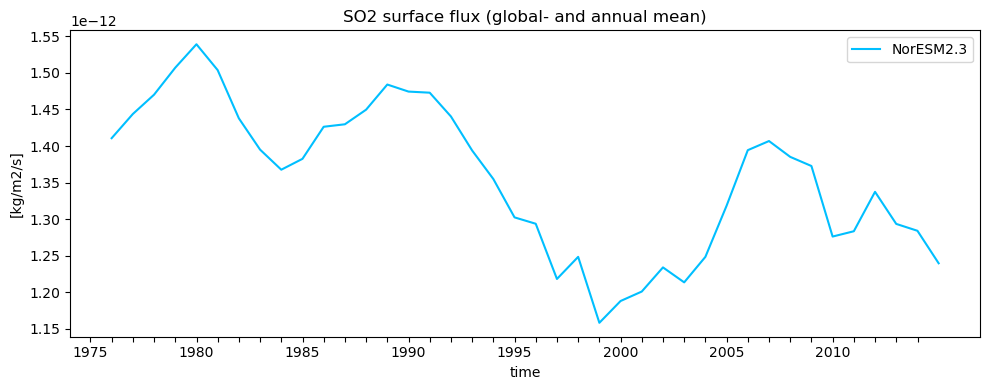

In [12]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
so2_surf = ds_19["SFSO2"].weighted(weighted_lat).mean(dim=["lat", "lon"])
so2_surf = so2_surf.resample(time="1YE").mean()



plt.figure(figsize=(10, 4))
so2_surf.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[kg/m2/s]")
years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.title("SO2 surface flux (global- and annual mean)")
plt.legend()
plt.tight_layout()
plt.show()

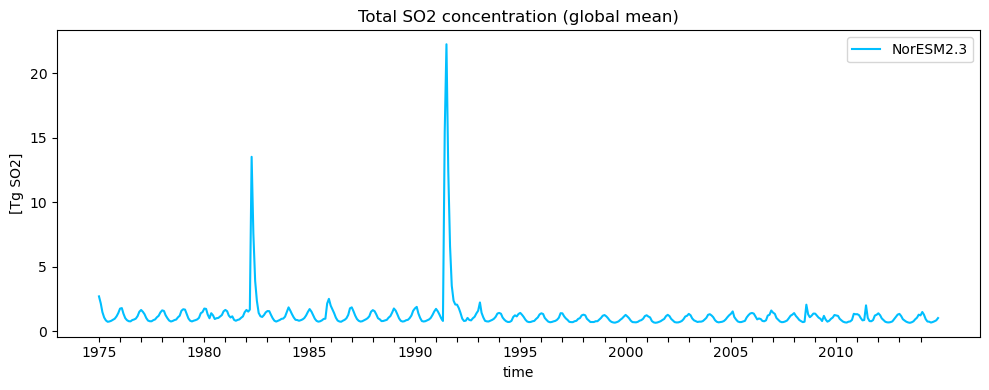

In [13]:
M_SO2 = 64.066     
M_air = 28.9647   
m_air_global = 5.3 * 10**21 
K_so2 = (M_SO2 / M_air) * m_air_global *10**(-12)    # mol/mol → Tg conversion factor

lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds_19["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

so2_tg = so2 * K_so2

plt.figure(figsize=(10, 4))
so2_tg.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[Tg SO2]")
years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.title("Total SO2 concentration (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

Text(0.5, 1.0, 'Total S concentration (global mean)')

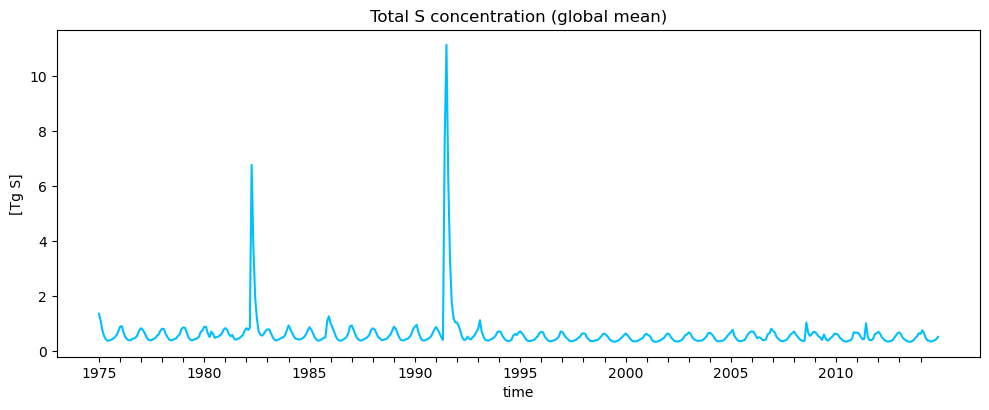

In [15]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds_19["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so2_tg = so2 * K

plt.figure(figsize=(10, 4))
so2_tg.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[Tg S]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.tight_layout()
plt.title("Total S concentration (global mean)")

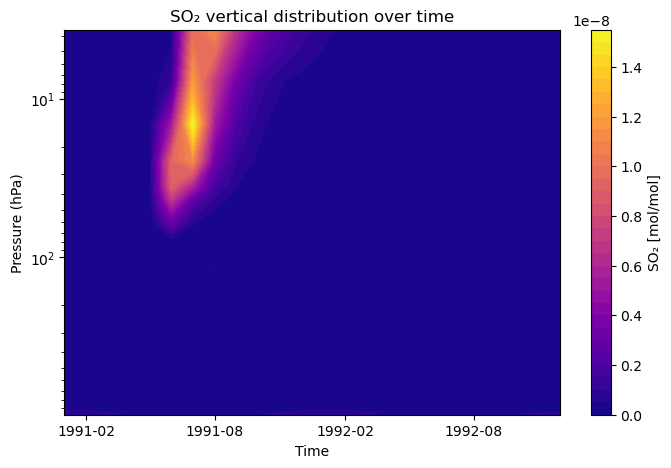

In [16]:
so2_profile = ds_19["SO2"].weighted(weighted_lat)
so2_time_lev = so2_profile.mean(dim=['lat','lon'])

so2_zoom = so2_time_lev.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom = so2_zoom['time'].values

time = ds_19['time'].values 
lev = ds_19['lev'].values

plt.figure(figsize=(8,5))
plt.contourf(time_zoom, lev, so2_zoom.T, levels=30, cmap='plasma')
plt.gca().invert_yaxis()
plt.yscale("log")
plt.colorbar(label='SO₂ [mol/mol]')
plt.xlabel('Time')
plt.ylabel('Pressure (hPa)')
plt.title('SO₂ vertical distribution over time')
plt.show()

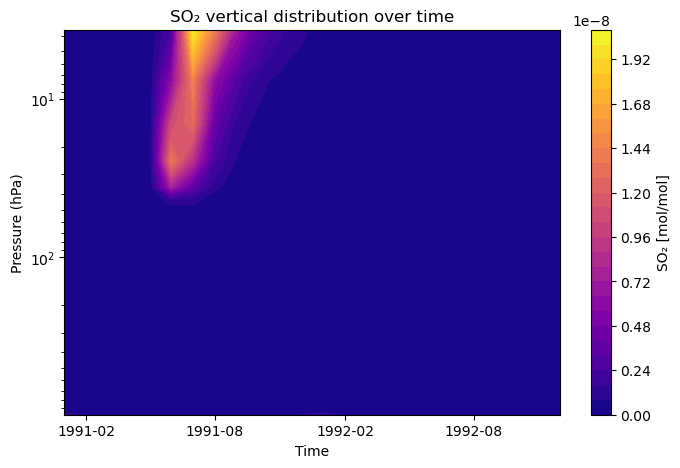

In [17]:
so2_profile = ds_22["SO2"].weighted(weighted_lat_22)
so2_time_lev = so2_profile.mean(dim=['lat','lon'])

so2_zoom = so2_time_lev.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom = so2_zoom['time'].values

time = ds_22['time'].values 
lev = ds_22['lev'].values

plt.figure(figsize=(8,5))
plt.contourf(time_zoom, lev, so2_zoom.T, levels=30, cmap='plasma')
plt.gca().invert_yaxis()
plt.yscale("log")
plt.colorbar(label='SO₂ [mol/mol]')
plt.xlabel('Time')
plt.ylabel('Pressure (hPa)')
plt.title('SO₂ vertical distribution over time')
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


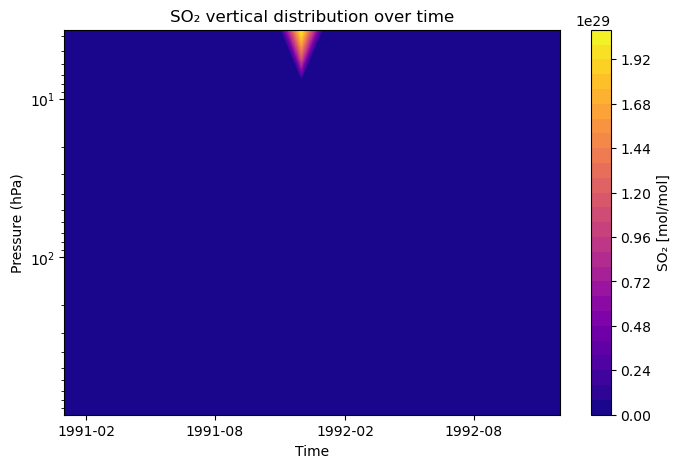

In [18]:
so2_profile = ds_19_c["SO2"].weighted(weighted_lat_19_c)
so2_time_lev = so2_profile.mean(dim=['lat','lon'])

so2_zoom = so2_time_lev.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom = so2_zoom['time'].values

time = ds_19_c['time'].values 
lev = ds_19_c['lev'].values

plt.figure(figsize=(8,5))
plt.contourf(time_zoom, lev, so2_zoom.T, levels=30, cmap='plasma')
plt.gca().invert_yaxis()
plt.yscale("log")
plt.colorbar(label='SO₂ [mol/mol]')
plt.xlabel('Time')
plt.ylabel('Pressure (hPa)')
plt.title('SO₂ vertical distribution over time')
plt.show()

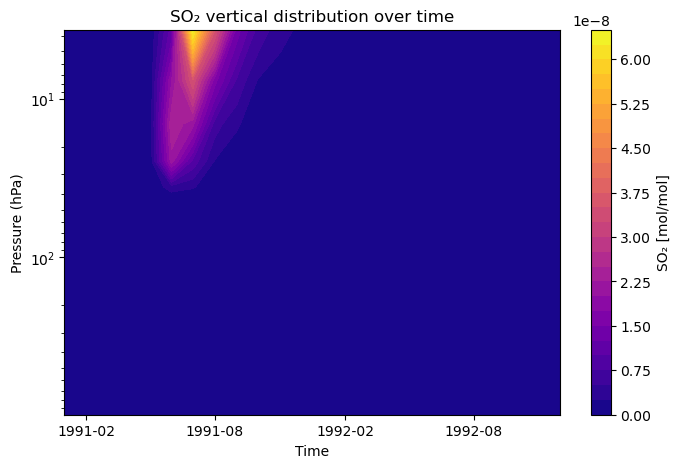

In [19]:
so2_profile = ds_24["SO2"].weighted(weighted_lat_24)
so2_time_lev = so2_profile.mean(dim=['lat','lon'])

so2_zoom = so2_time_lev.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom = so2_zoom['time'].values

time = ds_24['time'].values 
lev = ds_24['lev'].values

plt.figure(figsize=(8,5))
plt.contourf(time_zoom, lev, so2_zoom.T, levels=30, cmap='plasma')
plt.gca().invert_yaxis()
plt.yscale("log")
plt.colorbar(label='SO₂ [mol/mol]')
plt.xlabel('Time')
plt.ylabel('Pressure (hPa)')
plt.title('SO₂ vertical distribution over time')
plt.show()

### H2SO4 and sulfate

Text(0.5, 1.0, 'Total H2SO4 concentration (global mean)')

Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


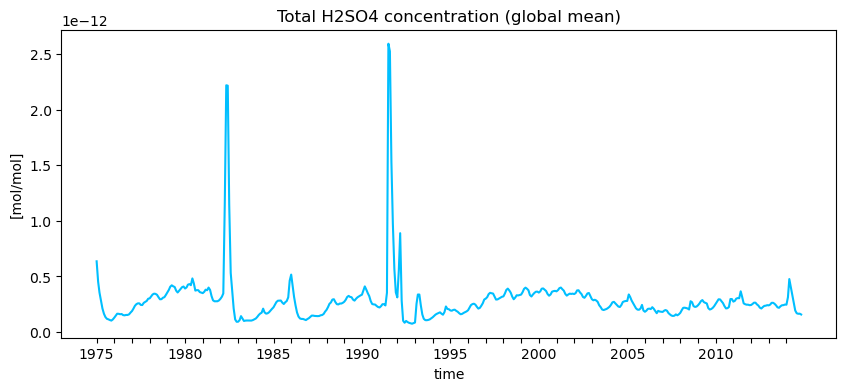

In [20]:
so4 = ds_19["H2SO4"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[mol/mol]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total H2SO4 concentration (global mean)")

Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Text(0.5, 1.0, 'Mass mixing ratio of Sulfate (global mean)')

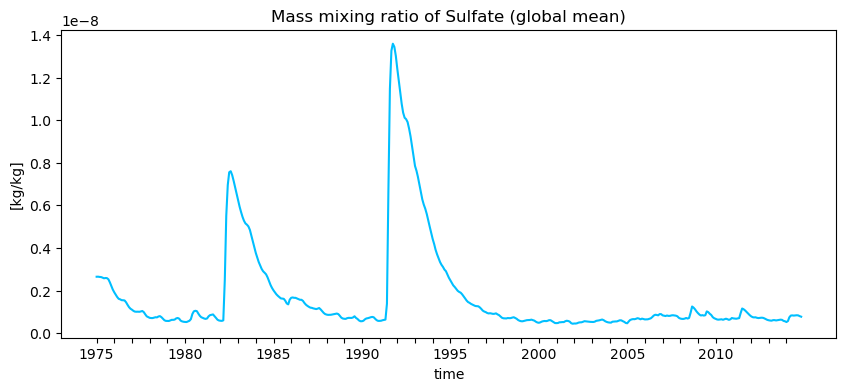

In [21]:
mmr_so4 = ds_19["mmr_SULFATE"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
mmr_so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[kg/kg]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Mass mixing ratio of Sulfate (global mean)")

In [22]:
tropopause = ds_19["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])

Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ni

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (global mean)')

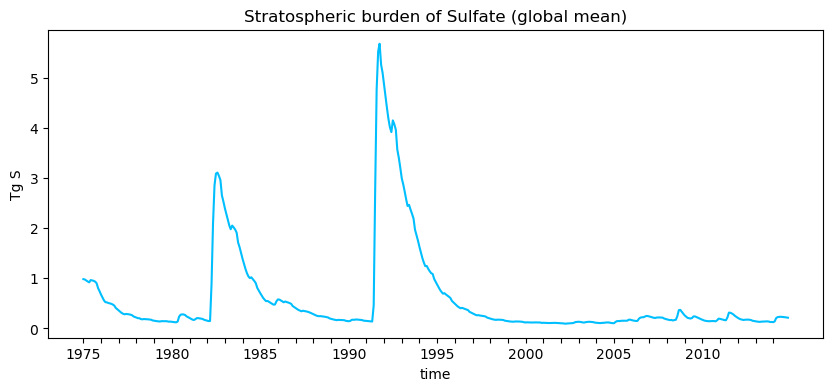

In [24]:
p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

mmr_sulf = ds_19["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd = so4_burd.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

mmr_sulf_22 = ds_22["mmr_SULFATE"]
so4_burd_22 = mmr_sulf_22.where(mmr_sulf_22["lev"] <= p_lev_22)
so4_burd_22 = so4_burd_22.weighted(weighted_lat_22).mean(dim=["lat", "lon", "lev"])
so4_burden_22 = so4_burd_22 * M_strat_air *10**(-12)
so4_burden_TgS_22 = so4_burden_22 * c

mmr_sulf_19_c = ds_19_c["mmr_SULFATE"]
so4_burd_19_c = mmr_sulf_19_c.where(mmr_sulf_19_c["lev"] <= p_lev_19_c)
so4_burd_19_c = so4_burd_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon", "lev"])
so4_burden_19_c = so4_burd_19_c * M_strat_air *10**(-12)
so4_burden_TgS_19_c = so4_burden_19_c * c

mmr_sulf_24 = ds_24["mmr_SULFATE"]
so4_burd_24 = mmr_sulf_24.where(mmr_sulf_24["lev"] <= p_lev_24)
so4_burd_24 = so4_burd_24.weighted(weighted_lat_24).mean(dim=["lat", "lon", "lev"])
so4_burden_24 = so4_burd_24 * M_strat_air *10**(-12)
so4_burden_TgS_24 = so4_burden_24 * c

plt.figure(figsize=(10, 4))
so4_burden_TgS.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (global mean)")

Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Text(0.5, 1.0, 'Stratospheric burden of Sulfate from Pinatubo (global mean) (-background)')

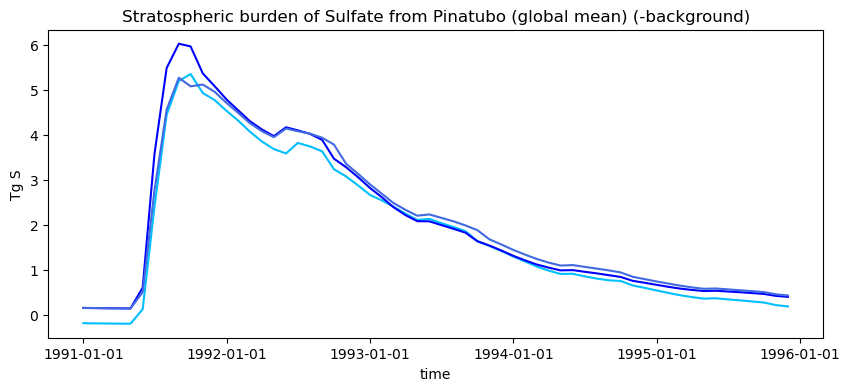

In [25]:
background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background
so4_burden_Pinatubo_22 = so4_burden_TgS_22
so4_burden_Pinatubo_19_c = so4_burden_TgS_19_c
so4_burden_Pinatubo_24 = so4_burden_TgS_24

plt.figure(figsize=(10, 4))
so4_burden_Pinatubo.plot(color = "deepskyblue", label = "NorESM2.3, all eruptions in: 10Tg, 19km")
so4_burden_Pinatubo_22.plot(color = "blue", label = "NorESM2.3: 10Tg, 22km")
so4_burden_Pinatubo_19_c.plot(color = "royalblue", label = "NorESM2.3: 10Tg, 19km")
years = np.arange(1991, 1997) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.xticks(
    year_ticks
)
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate from Pinatubo (global mean) (-background)")

In [26]:
a_glob = 510000000
h_trop = 4440
d = 12756

a_trop = np.pi * d * h_trop
ratio = a_trop/a_glob

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (Tropics)')

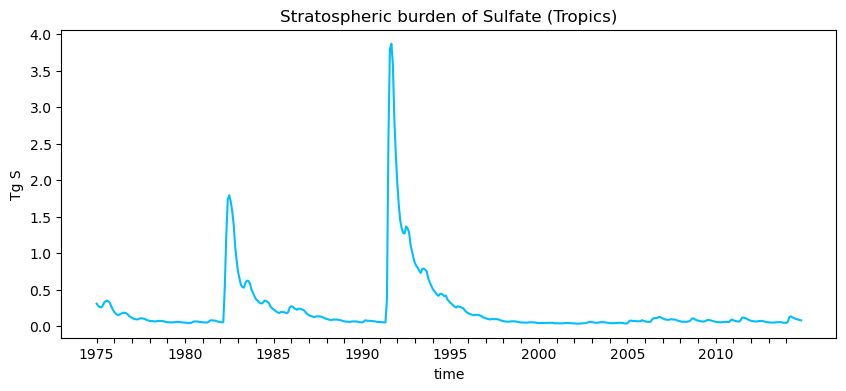

Exception ignored in: <function CachingFileManager.__del__ at 0x7fe38cd7f1a0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [ ]:
so4_trop = mmr_sulf.sel(lat=slice(-20, 20))
so4_burd_trop = so4_trop.where(so4_trop["lev"] <= p_lev)
so4_burd_trop = so4_burd_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden_trop = so4_burd_trop * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop = so4_burden_trop * c
so4_burden_TgS_trop_Pin = so4_burden_TgS_trop.sel(time=[t for t in so4_burden_TgS_trop.time.values if 1991 <= t.year <= 1995])

so4_trop_22 = mmr_sulf_22.sel(lat=slice(-20, 20))
so4_burd_trop_22 = so4_trop_22.where(so4_trop_22["lev"] <= p_lev_22)
so4_burd_trop_22 = so4_burd_trop_22.weighted(weighted_lat_22).mean(dim=["lat", "lon", "lev"])
so4_burden_trop_22 = so4_burd_trop_22 * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_22 = so4_burden_trop_22 * c

so4_trop_19_c = mmr_sulf_19_c.sel(lat=slice(-20, 20))
so4_burd_trop_19_c = so4_trop_19_c.where(so4_trop_19_c["lev"] <= p_lev_19_c)
so4_burd_trop_19_c = so4_burd_trop_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon", "lev"])
so4_burden_trop_19_c = so4_burd_trop_19_c * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_19_c = so4_burden_trop_19_c * c

so4_trop_24= mmr_sulf_24.sel(lat=slice(-20, 20))
so4_burd_trop_24 = so4_trop_24.where(so4_trop_24["lev"] <= p_lev_24)
so4_burd_trop_24 = so4_burd_trop_24.weighted(weighted_lat_24).mean(dim=["lat", "lon", "lev"])
so4_burden_trop_24 = so4_burd_trop_24 * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_24 = so4_burden_trop_24 * c

plt.figure(figsize=(10, 4))
so4_burden_TgS_trop.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (Tropics)")

In [28]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"

In [29]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

/tmp/ipykernel_3300081/1286819563.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_3300081/1286819563.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


2025-12-02 16:11:11,479 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:46549
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/worker.py", line 2073, in gather_dep
    response = await get_data_from_worker(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
        rpc=self.rpc, keys=to_gather, worker=worker, who=self.address
       

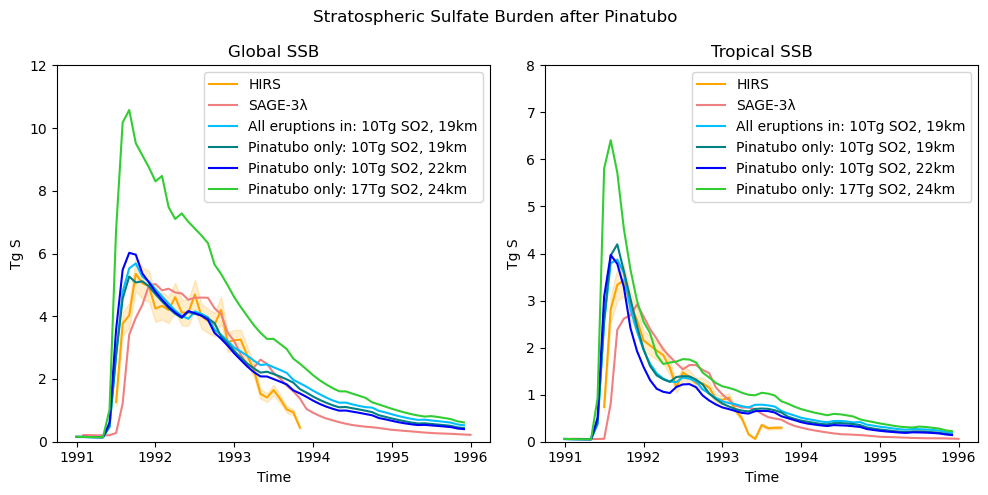

In [33]:
total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)
total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)

obs_time = np.array([t.year + (t.month-1)/12 for t in total_sage.index])
obs_time_hirs = np.array([t.year + (t.month-1)/12 for t in total.index])
time_years = np.array([t.year + (t.month-1)/12 for t in so4_burd_Pinatubo.time.values])
time_years_22 = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_22.time.values])
time_years_19_c = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_19_c.time.values])
time_years_24 = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_24.time.values])

obs_time_trop = np.array([t.year + (t.month-1)/12 for t in trop_sage.index])
obs_time_hirs_trop = np.array([t.year + (t.month-1)/12 for t in trop.index])
time_years_trop = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_Pin.time.values])
time_years_trop_22 = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_22.time.values])
time_years_trop_19_c = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_19_c.time.values])
time_years_trop_24 = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_24.time.values])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(obs_time_hirs, total, color="orange", label="HIRS")
ax[0].fill_between(obs_time_hirs, total - err_total, total + err_total,
                 color="orange", alpha=0.2)
ax[0].plot(obs_time, total_sage, color="lightcoral", label="SAGE-3λ")
ax[0].plot(time_years, so4_burd_Pinatubo, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
ax[0].plot(time_years_19_c, so4_burden_Pinatubo_19_c, color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
ax[0].plot(time_years_22, so4_burden_Pinatubo_22, color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
ax[0].plot(time_years_24, so4_burden_Pinatubo_24, color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Tg S")
ax[0].set_ylim(0,12)
ax[0].set_title("Global SSB")
ax[0].legend()

ax[1].plot(obs_time_hirs_trop,  trop,  color="orange", label="HIRS")
ax[1].fill_between(obs_time_hirs_trop, trop - err_trop, trop + err_trop,
                 color="orange", alpha=0.2)
ax[1].plot(obs_time_trop, trop_sage, color="lightcoral", label="SAGE-3λ")
ax[1].plot(time_years_trop, so4_burden_TgS_trop_Pin, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km" )
ax[1].plot(time_years_trop_19_c, so4_burden_TgS_trop_19_c, color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
ax[1].plot(time_years_trop_22, so4_burden_TgS_trop_22, color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
ax[1].plot(time_years_trop_24, so4_burden_TgS_trop_24, color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Tg S")
ax[1].set_ylim(0,8)
ax[1].set_title("Tropical SSB")
ax[1].legend()


fig.suptitle("Stratospheric Sulfate Burden after Pinatubo")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Sulphur in form of SO2 and SO4 after Pinatubo')

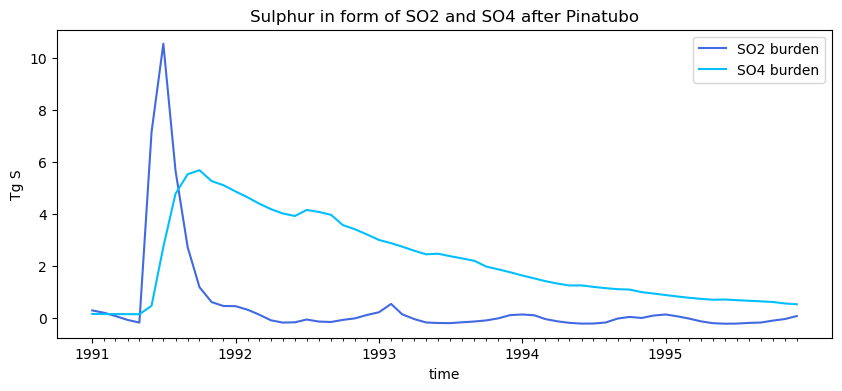

In [34]:
bg = so2_tg.sel(time=[t for t in so2_tg.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so2_Pinatubo = so2_tg.sel(time=[t for t in so2_tg.time.values if 1991 <= t.year <= 1995])
so2_burden_Pinatubo = so2_Pinatubo - bg

"""background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background"""

plt.figure(figsize=(10, 4))
so2_burden_Pinatubo.plot(color = "royalblue", label = "SO2 burden")
so4_burd_Pinatubo.plot(color = "deepskyblue", label = "SO4 burden")
years = np.arange(1991, 1996) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
month_ticks = [cftime.DatetimeNoLeap(y, m, 1) for y in years for m in range(1, 13)]
plt.xticks(year_ticks, [str(y) for y in years])
ax = plt.gca()
ax.set_xticks(month_ticks, minor=True)
plt.ylabel("Tg S")
plt.legend()
plt.title("Sulphur in form of SO2 and SO4 after Pinatubo")

<Figure size 700x500 with 0 Axes>

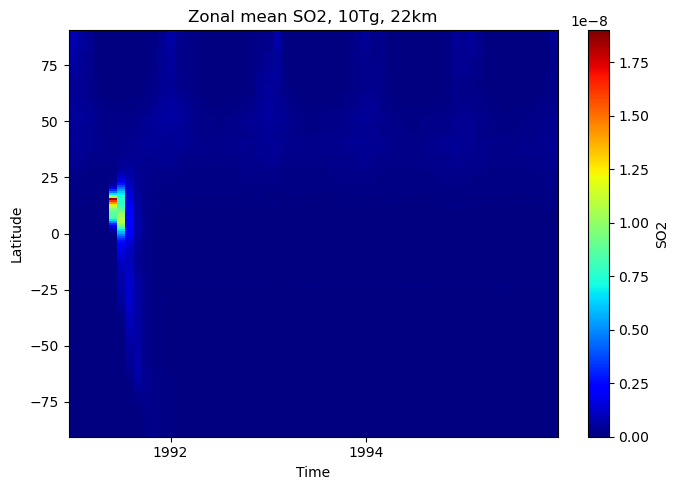

In [35]:
so2 = ds_22["SO2"].weighted(weighted_lat_22).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 22km")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

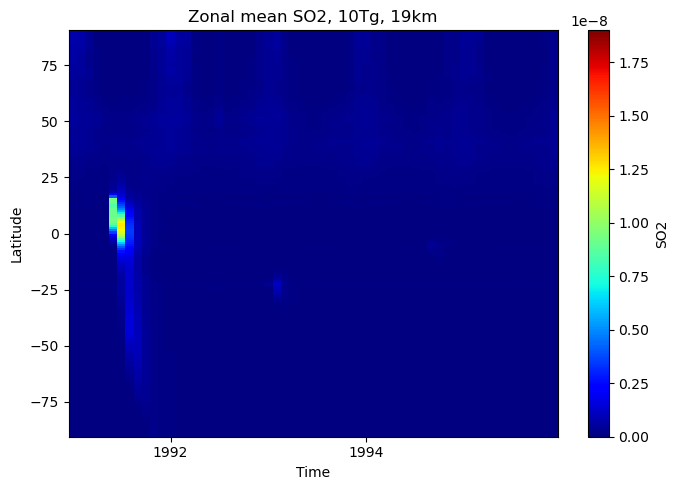

In [38]:
so2 = ds_19["SO2"].weighted(weighted_lat).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 19km")
plt.tight_layout()
plt.show()

### AOD

In [39]:
glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)

/tmp/ipykernel_3300081/2537514140.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_3300081/2537514140.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)


In [40]:
start = pd.Timestamp("1991-01-01")
months_glossac = [int(c) for c in glossac_saod.columns]
dates_glossac = [start + pd.DateOffset(months=m) for m in months_glossac]
glossac_saod.columns = dates_glossac

months_avhrr = [int(c) for c in avhrr_saod.columns] 
dates_avhrr = [start + pd.DateOffset(months=m) for m in months_avhrr]
avhrr_saod.columns = dates_avhrr

In [41]:
avhrr_global = avhrr_saod.loc["Global_mean"].astype(float)
glossac_global = glossac_saod.loc["Global_mean"].astype(float)

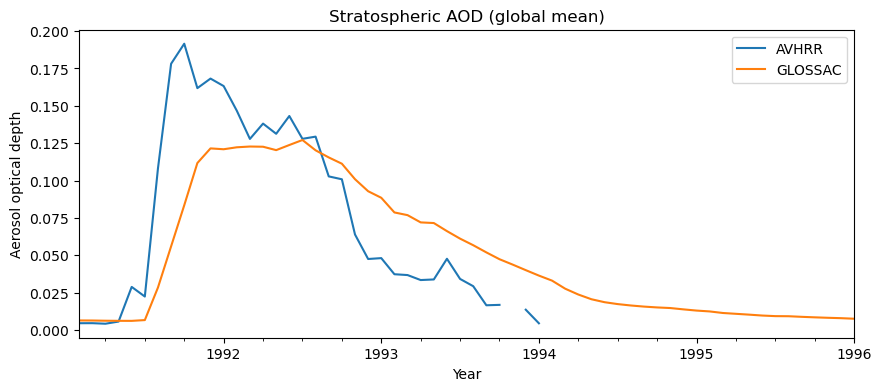

In [42]:
plt.figure(figsize=(10, 4))
avhrr_global.plot(label = "AVHRR")
glossac_global.plot(label="GLOSSAC")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
plt.legend()
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7faecd6bb060>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


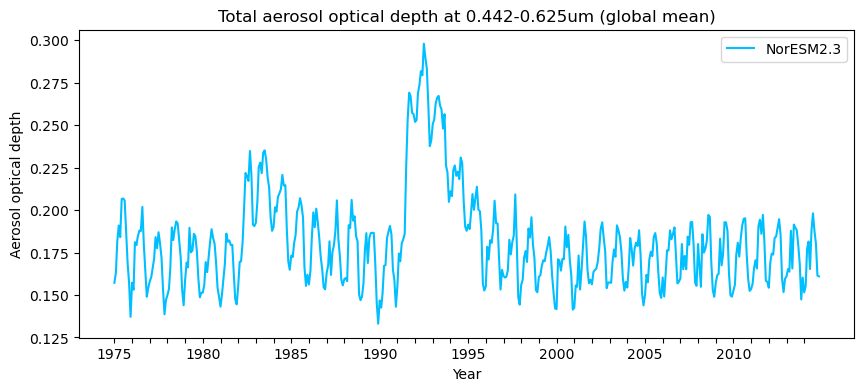

In [43]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = ds_19[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds_19[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()
ts_aod_22 = ds_22[aod500].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = ds_22[daylight].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22 = ts_aod_22 / daylight_monthly_22
ts_aod_19_c = ds_19_c[aod500].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = ds_19_c[daylight].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c = ts_aod_19_c / daylight_monthly_19_c
ts_aod_24 = ds_24[aod500].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24= ds_24[daylight].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24 = ts_aod_24 / daylight_monthly_24

plt.figure(figsize=(10, 4))
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.show()


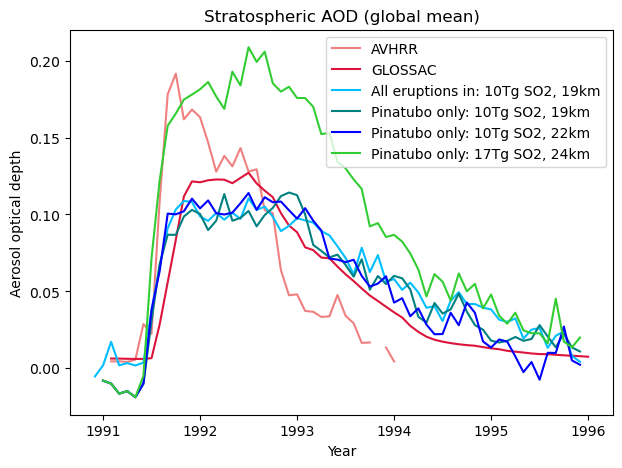

In [44]:
pre_eruption = ts_aod.sel(time=slice("1976-01", "1981-12"))
base = pre_eruption.groupby("time.month").mean("time")
aod_anom = ts_aod.groupby("time.month") - base
aod_anom_22 = ts_aod_22.groupby("time.month") - base
aod_anom_19_c = ts_aod_19_c.groupby("time.month") - base
aod_anom_24 = ts_aod_24.groupby("time.month") - base
#pre_eruption = ts_aod.sel(time=slice("2001-01", "2005-12")).mean(dim="time")
#aod_anom = ts_aod - pre_eruption
aod_Pinatubo = aod_anom.sel(time=slice("1990-12", "1995-12"))
aod_smooth = aod_Pinatubo.rolling(time=1, center=True).mean()

obs_time_avhrr = np.array([t.year + (t.month-1)/12 for t in avhrr_global.index])
obs_time_glossac = np.array([t.year + (t.month-1)/12 for t in glossac_global.index])
time_years = np.array([t.year + (t.month-1)/12 for t in aod_Pinatubo.time.values])
time_years_22 = np.array([t.year + (t.month-1)/12 for t in aod_anom_22.time.values])
time_years_19_c = np.array([t.year + (t.month-1)/12 for t in aod_anom_19_c.time.values])
time_years_24 = np.array([t.year + (t.month-1)/12 for t in aod_anom_24.time.values])

plt.figure(figsize=(7, 5))
plt.plot(obs_time_avhrr, avhrr_global, color = "lightcoral", label = "AVHRR")
plt.plot(obs_time_glossac, glossac_global, color = "crimson", label = "GLOSSAC")
plt.plot(time_years, aod_Pinatubo, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(time_years_19_c, aod_anom_19_c, color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(time_years_22, aod_anom_22, color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(time_years_24, aod_anom_24, color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
plt.legend()
plt.show()

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


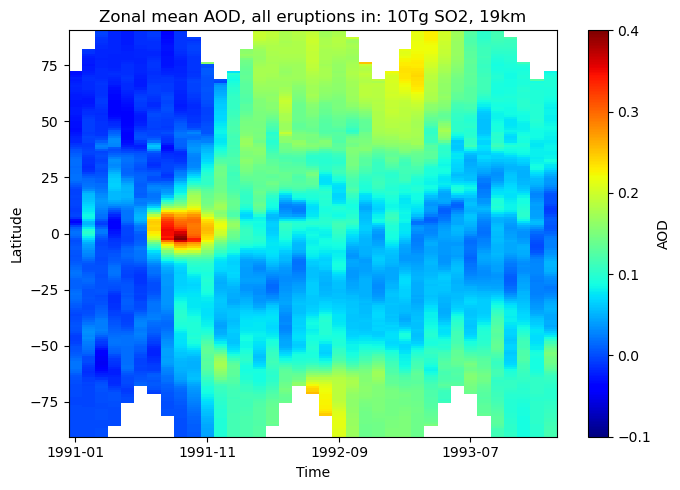

In [54]:
aod = ds_19[aod500]
daylight_monthly_nw = ds_19[daylight]
aod = aod / daylight_monthly_nw

baseline = aod.sel(time=slice("1976-01", "1981-12"))
base = baseline.groupby("time.month").mean("time")
aod_strat = aod.groupby("time.month") - base

aod_zoom = aod_strat.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom = aod_zoom['time'].values
aod_lat_time = aod_zoom.mean(dim="lon")
lat = aod_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    aod_lat_time.T,
    vmax = 0.4,
    vmin = -0.1, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD, all eruptions in: 10Tg SO2, 19km")
plt.tight_layout()
plt.show()

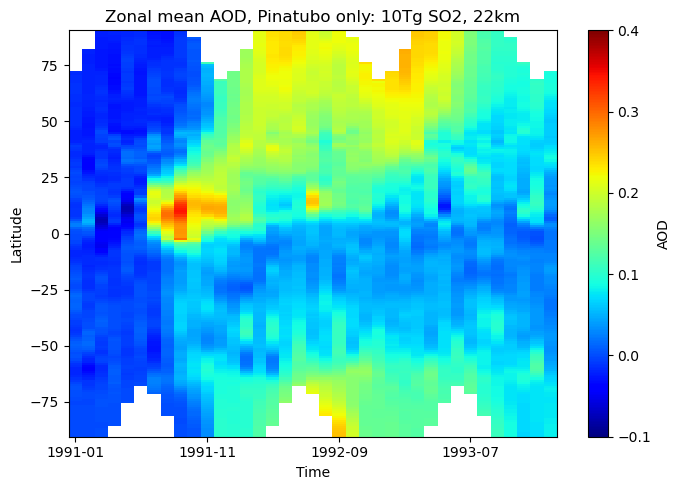

In [55]:
aod_22 = ds_22[aod500]
daylight_monthly_nw_22 = ds_22[daylight]
aod_22 = aod_22 / daylight_monthly_nw_22
aod_strat_22 = aod_22.groupby("time.month") - base

aod_zoom_22 = aod_strat_22.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_22 = aod_zoom_22['time'].values
aod_lat_time_22 = aod_zoom_22.mean(dim="lon")
lat_22 = aod_lat_time_22["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom_22,
    lat_22,
    aod_lat_time_22.T, 
    vmax = 0.4,
    vmin = -0.1, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD, Pinatubo only: 10Tg SO2, 22km")
plt.tight_layout()
plt.show()

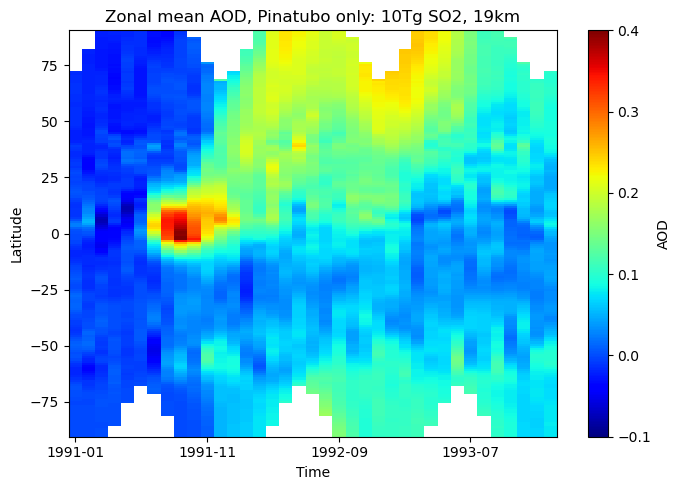

In [56]:
aod_19_c = ds_19_c[aod500]
daylight_monthly_nw_19_c = ds_19_c[daylight]
aod_19_c = aod_19_c / daylight_monthly_nw_19_c
aod_strat_19_c = aod_19_c.groupby("time.month") - base

aod_zoom_19_c = aod_strat_19_c.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_19_c = aod_zoom_19_c['time'].values
aod_lat_time_19_c = aod_zoom_19_c.mean(dim="lon")
lat_19_c = aod_lat_time_19_c["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom_19_c,
    lat_19_c,
    aod_lat_time_19_c.T, 
    vmax = 0.4,
    vmin = -0.1, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD, Pinatubo only: 10Tg SO2, 19km")
plt.tight_layout()
plt.show()

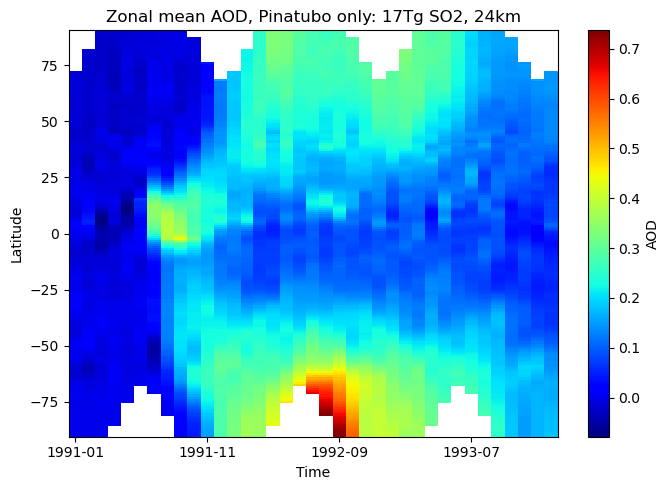

In [58]:
aod_24 = ds_24[aod500]
daylight_monthly_nw_24 = ds_24[daylight]
aod_24 = aod_24 / daylight_monthly_nw_24
aod_strat_24= aod_24.groupby("time.month") - base

aod_zoom_24 = aod_strat_24.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_24 = aod_zoom_24['time'].values
aod_lat_time_24 = aod_zoom_24.mean(dim="lon")
lat_24 = aod_lat_time_24["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom_24,
    lat_24,
    aod_lat_time_24.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD, Pinatubo only: 17Tg SO2, 24km")
plt.tight_layout()
plt.show()

## Ozone

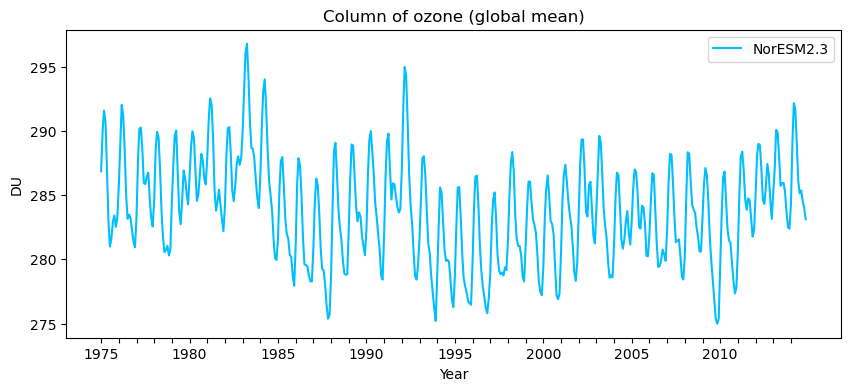

In [59]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

o3 = ds_19[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU

plt.figure(figsize=(10, 4))
o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("Column of ozone (global mean)")
plt.legend()
plt.show()

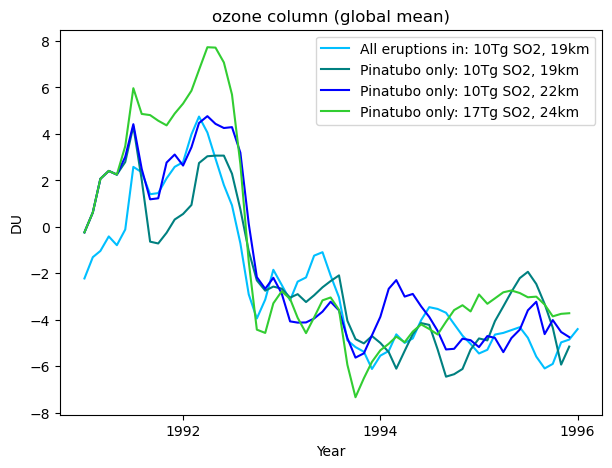

In [62]:
o3 = ds_19[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU
baseline = o3.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")
o3_anom = o3.groupby("time.month") - base
o3_anom = o3_anom.sel(time=slice('1991-01-01', '1996-01-01'))
o3_22 = ds_22[cb_o3].weighted(weighted_lat_22).mean(dim=["lat", "lon"]) * DU
o3_22_anom = o3_22.groupby("time.month") - base
o3_19_c = ds_19_c[cb_o3].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"]) * DU
o3_19_c_anom = o3_19_c.groupby("time.month") - base
o3_24 = ds_24[cb_o3].weighted(weighted_lat_24).mean(dim=["lat", "lon"]) * DU
o3_24_anom = o3_24.groupby("time.month") - base

plt.figure(figsize=(7, 5))
plt.plot(o3_anom.time, o3_anom, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(o3_19_c_anom.time, o3_19_c_anom, color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(o3_22_anom.time, o3_22_anom, color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(o3_24_anom.time, o3_24_anom, color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("ozone column (global mean)")
plt.legend()
plt.show()

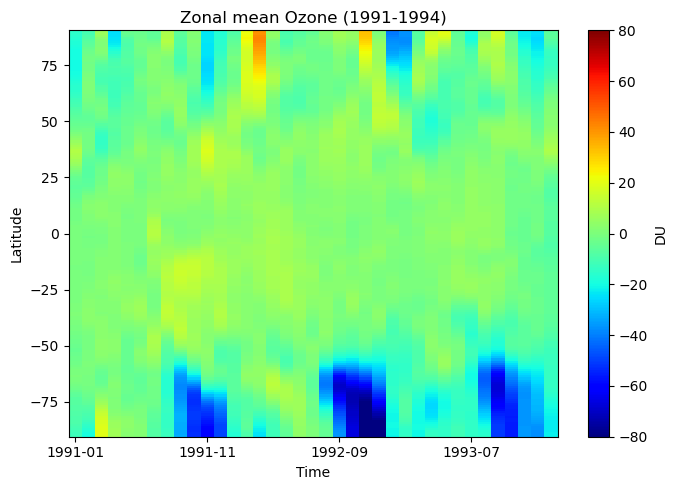

In [63]:
o3_cb = ds_19[cb_o3]
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")
o3_anom = o3_cb.groupby("time.month") - base

o3_zoom= o3_anom.sel(time=slice('1991-01-01', '1994-01-01'))
o3_mean = o3_zoom.mean(dim="lon") * DU
lat_o3 = o3_mean["lat"]
time_o3 = o3_zoom["time"].values

plt.figure(figsize=(7,5))
ax = plt.subplot()
pc = ax.pcolormesh(
    time_o3,
    lat_o3,
    o3_mean.T, 
    shading="auto",  
    cmap="jet",
    vmin=-80,   
    vmax=80  
)
plt.colorbar(pc, ax=ax, label="DU")
ax.set_xlabel("Time")
ax.set_ylabel("Latitude")
ax.set_title("Zonal mean Ozone (1991-1994)")
plt.tight_layout()
plt.show()

### Effective radius

In [64]:
sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)

/tmp/ipykernel_3300081/4263974375.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)


In [65]:
months_sageii = [int(c) for c in sageii_tropreff.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropreff.columns = dates_sageii

In [66]:
strat_reff_sageii = sageii_tropreff.loc["Strat_mean_sad_weighted"].astype(float)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f8444d0b380>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


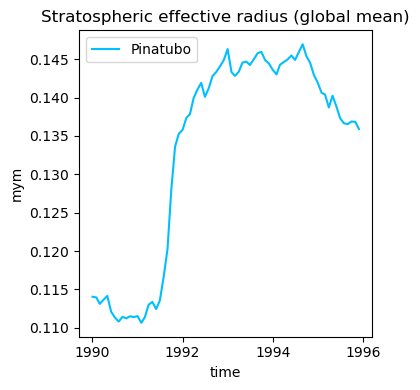

In [67]:
cm_to_mym = 10000
tropopause = ds_19["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01
SReff = ds_19["REFF_AERO"].where(ds_19["REFF_AERO"]["lev"] <= p_lev)
SReff = SReff.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])*cm_to_mym
SReff = SReff.sel(time=slice("1990-01-01", "1995-12-31"))

plt.figure(figsize=(4, 4))
SReff.plot(color = "deepskyblue", label = "Pinatubo")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (global mean)")
plt.legend()
plt.tight_layout()

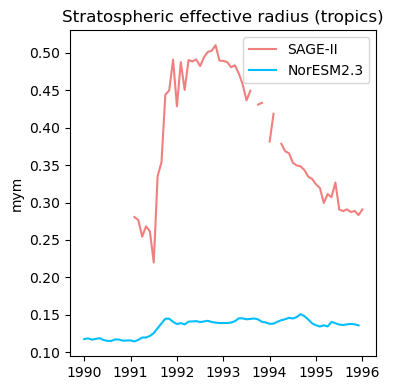

In [68]:
SReff = ds_19["REFF_AERO"].where(ds_19["REFF_AERO"]["lev"] <= p_lev)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_trop = SReff_trop.sel(time=slice("1990-01-01", "1995-12-31"))

obs_time_sageii = np.array([t.year + (t.month-1)/12 for t in strat_reff_sageii.index])
time_years = np.array([t.year + (t.month-1)/12 for t in SReff_trop.time.values])

plt.figure(figsize=(4, 4))
plt.plot(obs_time_sageii, strat_reff_sageii, color = "lightcoral", label = "SAGE-II")
plt.plot(time_years, SReff_trop, color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (tropics)")
plt.legend()
plt.tight_layout()